In [71]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [6]:
df=pd.read_csv("loan_approval_data.csv")

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

In [8]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [9]:
df.shape

(1000, 20)

In [11]:
df.columns
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [17]:
categorical_cols= df.select_dtypes(include=['object']).columns
number_cols=df.select_dtypes(include=['float64']).columns

C:\Users\jangi\AppData\Local\Temp\ipykernel_17156\1659189326.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols= df.select_dtypes(include=['object']).columns


In [19]:
number_imp=SimpleImputer(strategy='mean')
df[number_cols]=number_imp.fit_transform(df[number_cols])

In [22]:
cat_imp=SimpleImputer(strategy='most_frequent')
df[categorical_cols]= cat_imp.fit_transform(df[categorical_cols])
df[categorical_cols]

,Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,Salaried,Married,Personal,Urban,Not Graduate,Female,Private,No
1,Salaried,Married,Car,Semiurban,Graduate,Male,Private,No
2,Salaried,Single,Business,Urban,Graduate,Female,Government,Yes
3,Salaried,Married,Business,Rural,Graduate,Female,Government,No
4,Self-employed,Single,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...
995,Salaried,Married,Personal,Urban,Not Graduate,Male,Unemployed,No
996,Self-employed,Married,Business,Urban,Graduate,Female,Government,No
997,Contract,Single,Home,Rural,Graduate,Male,MNC,No
998,Unemployed,Single,Personal,Urban,Graduate,Male,Private,Yes


In [23]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

Text(0.5, 1.0, 'is loan passed or not ? ')

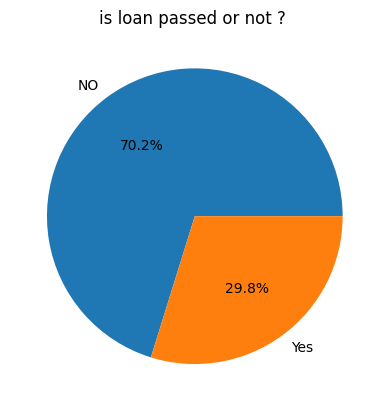

In [25]:
classes_count=df['Loan_Approved'].value_counts()
plt.pie(classes_count,labels=['NO','Yes'],autopct='%1.1f%%')
plt.title('is loan passed or not ? ')

AttributeError: 'Axes' object has no attribute 'Container'

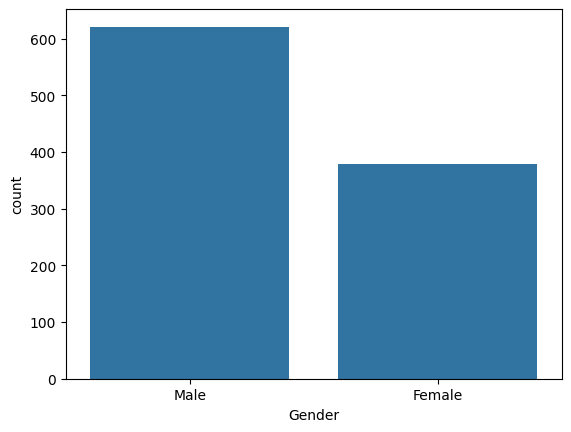

In [26]:
gender_cnt= df['Gender'].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.Container[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

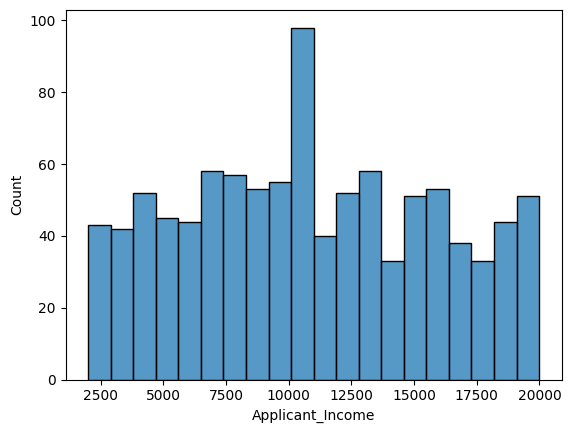

In [28]:
sns.histplot(
    data=df,
    x ='Applicant_Income',
    bins=20
    
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

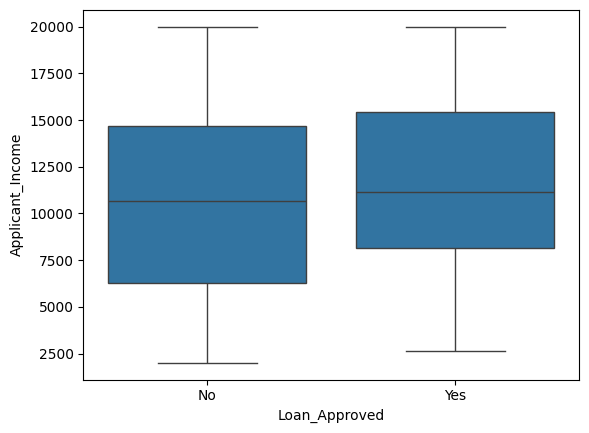

In [29]:
sns.boxplot(
    data=df,
    x='Loan_Approved',
    y='Applicant_Income'
)

In [34]:
df.columns


Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='str')

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

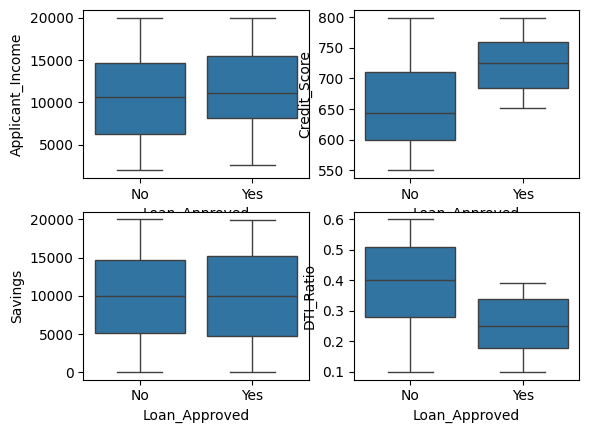

In [39]:
fig , axes=plt.subplots(2,2)

sns.boxplot(ax=axes[0,0],
             data=df,
              x='Loan_Approved',
              y='Applicant_Income'

             )

sns.boxplot(ax=axes[0,1],
             data=df,
              x='Loan_Approved',
              y='Credit_Score'

             )

sns.boxplot(ax=axes[1,1],
             data=df,
              x='Loan_Approved',
              y='DTI_Ratio'

             )


sns.boxplot(ax=axes[1,0],
             data=df,
              x='Loan_Approved',
              y='Savings'

             )


<Axes: xlabel='Credit_Score', ylabel='Count'>

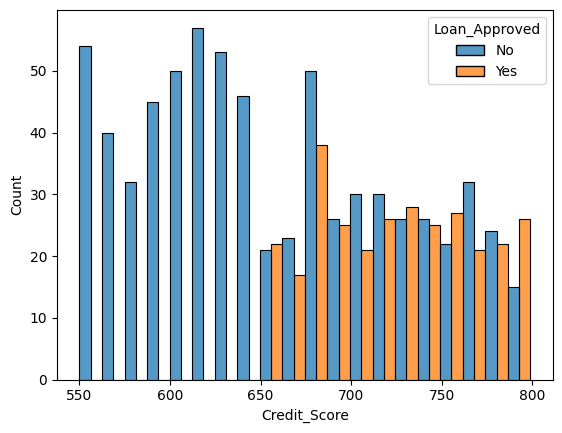

In [41]:
sns.histplot(
    data=df,
    x='Credit_Score',
    hue='Loan_Approved',
    bins=20,
    multiple='dodge'
    
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

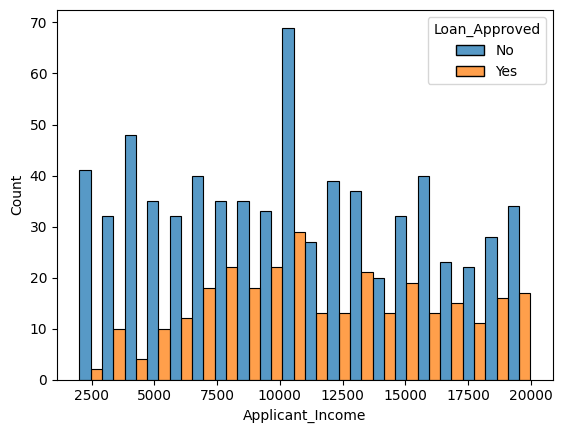

In [42]:
sns.histplot(
    data=df,
    x='Applicant_Income',
    hue='Loan_Approved',
    bins=20,
    multiple='dodge'
    
)

In [43]:
df=df.drop('Applicant_Income',axis=1)

In [44]:
df.columns

Index(['Applicant_ID', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='str')

In [49]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

In [50]:
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [51]:
df

,Applicant_ID,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Loan_Approved,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Not Graduate,No,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Graduate,No,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Graduate,Yes,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Graduate,No,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Graduate,Yes,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Not Graduate,No,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,997.0,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Graduate,No,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,998.0,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Graduate,No,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,999.0,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Graduate,Yes,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [52]:
le = LabelEncoder()

df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [53]:
df

,Applicant_ID,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Loan_Approved,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,0,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,997.0,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,998.0,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,999.0,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,0,1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [54]:
num_cols= df.select_dtypes(include='number')
corr_matrix=num_cols.corr()


In [56]:
num_cols.corr()['Loan_Approved'].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

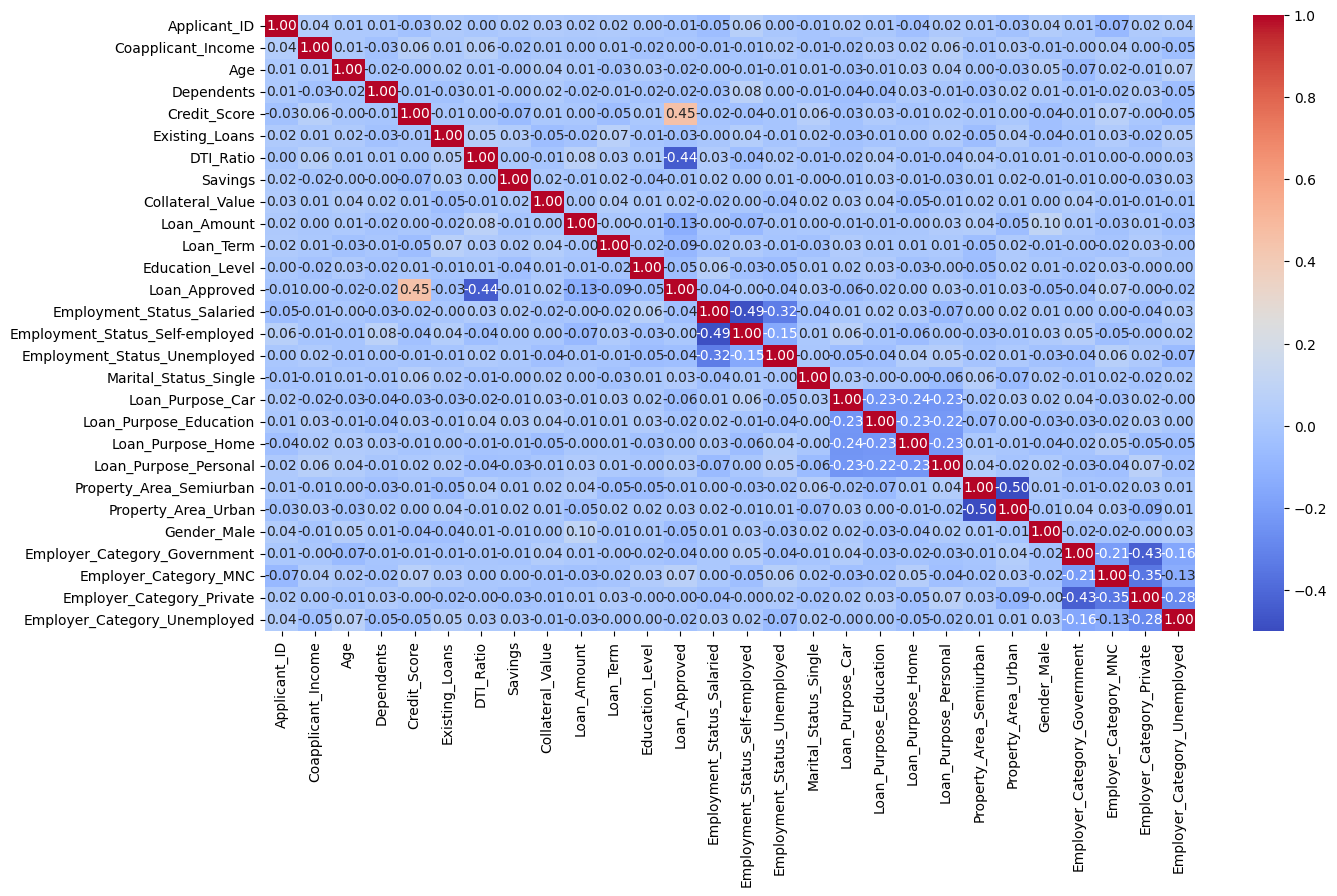

In [60]:
plt.figure(figsize=(15,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

In [61]:
X=df.drop('Loan_Approved',axis=1)
y=df['Loan_Approved']

In [62]:
X

,Applicant_ID,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,997.0,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,998.0,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,999.0,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [64]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [65]:
scaler= StandardScaler()

In [73]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [74]:
log_model=LogisticRegression()

log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)


print("Precision Score is : ",precision_score(y_test,y_pred))
print("Accuracy Score is : ",accuracy_score(y_test,y_pred))
print("Recall Score is : ",recall_score(y_test,y_pred))
print("R2 Score is : ",r2_score(y_test,y_pred))
print("F1 Score is : ",f1_score(y_test,y_pred))
print("Confusion matrix  is : ",confusion_matrix(y_test,y_pred))

# Precision Score is :  0.7704918032786885
# Accuracy Score is :  0.86
# Recall Score is :  0.7704918032786885
# R2 Score is :  0.3395447576365138
# F1 Score is :  0.7704918032786885
# Confusion matrix  is :  
#  [[125  14]
#  [ 14  47]]

Precision Score is :  0.7704918032786885
Accuracy Score is :  0.86
Recall Score is :  0.7704918032786885
R2 Score is :  0.3395447576365138
F1 Score is :  0.7704918032786885
Confusion matrix  is :  [[125  14]
 [ 14  47]]


In [75]:
Knn_model=KNeighborsClassifier()

Knn_model.fit(X_train_scaled,y_train)
y_pred=Knn_model.predict(X_test_scaled)


print("Precision Score is : ",precision_score(y_test,y_pred))
print("Accuracy Score is : ",accuracy_score(y_test,y_pred))
print("Recall Score is : ",recall_score(y_test,y_pred))
print("R2 Score is : ",r2_score(y_test,y_pred))
print("F1 Score is : ",f1_score(y_test,y_pred))
print("Confusion matrix  is : ",confusion_matrix(y_test,y_pred))

# Precision Score is :  0.5652173913043478
# Accuracy Score is :  0.725
# Recall Score is :  0.4262295081967213
# R2 Score is :  -0.297322797499705
# F1 Score is :  0.48598130841121495
# Confusion matrix  is :  
#  [[119  20]
#  [ 35  26]]


Precision Score is :  0.5652173913043478
Accuracy Score is :  0.725
Recall Score is :  0.4262295081967213
R2 Score is :  -0.297322797499705
F1 Score is :  0.48598130841121495
Confusion matrix  is :  [[119  20]
 [ 35  26]]


In [76]:
bayes_model=GaussianNB()

bayes_model.fit(X_train_scaled,y_train)
y_pred=bayes_model.predict(X_test_scaled)


print("Precision Score is : ",precision_score(y_test,y_pred))
print("Accuracy Score is : ",accuracy_score(y_test,y_pred))
print("Recall Score is : ",recall_score(y_test,y_pred))
print("R2 Score is : ",r2_score(y_test,y_pred))
print("F1 Score is : ",f1_score(y_test,y_pred))
print("Confusion matrix  is : ",confusion_matrix(y_test,y_pred))



# Precision Score is :  0.7777777777777778
# Accuracy Score is :  0.845
# Recall Score is :  0.6885245901639344
# R2 Score is :  0.2687816959547117
# F1 Score is :  0.7304347826086957
# Confusion matrix  is : 
#  [[127  12]
#  [ 19  42]]

Precision Score is :  0.7777777777777778
Accuracy Score is :  0.845
Recall Score is :  0.6885245901639344
R2 Score is :  0.2687816959547117
F1 Score is :  0.7304347826086957
Confusion matrix  is :  [[127  12]
 [ 19  42]]


In [77]:
df.columns

Index(['Applicant_ID', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level',
       'Loan_Approved', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education',
       'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed'],
      dtype='str')

In [80]:
df['DTI_Ratio_sq']=df['DTI_Ratio'] ** 2
df['Credit_Score_sq']=df['Credit_Score'] ** 2

X=df.drop(columns=['Loan_Approved','Credit_Score','DTI_Ratio'])
y=df['Loan_Approved']


log_model=LogisticRegression()

log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)


print("Precision Score is : ",precision_score(y_test,y_pred))
print("Accuracy Score is : ",accuracy_score(y_test,y_pred))
print("Recall Score is : ",recall_score(y_test,y_pred))
print("R2 Score is : ",r2_score(y_test,y_pred))
print("F1 Score is : ",f1_score(y_test,y_pred))
print("Confusion matrix  is : ",confusion_matrix(y_test,y_pred))


# Precision Score is :  0.7704918032786885
# Accuracy Score is :  0.86
# Recall Score is :  0.7704918032786885
# R2 Score is :  0.3395447576365138
# F1 Score is :  0.7704918032786885
# Confusion matrix  is :  [[125  14]
#  [ 14  47]] 

Precision Score is :  0.7704918032786885
Accuracy Score is :  0.86
Recall Score is :  0.7704918032786885
R2 Score is :  0.3395447576365138
F1 Score is :  0.7704918032786885
Confusion matrix  is :  [[125  14]
 [ 14  47]]
